# UniversalStripeRemover — Tiled Batch Processing Test

Tests `process_tiled()` with **n=1** (no split), **n=2** (2×2), **n=3** (3×3).  
Each configuration tiles the image, processes all tiles as a batch, then reassembles with cosine overlap blending.

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import time

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.9.1+cu126
CUDA: True
GPU: NVIDIA GeForce RTX 2060


## 1. Load Sample Image

Image shape: torch.Size([487, 757])
Value range: [0.1333, 1.0000]


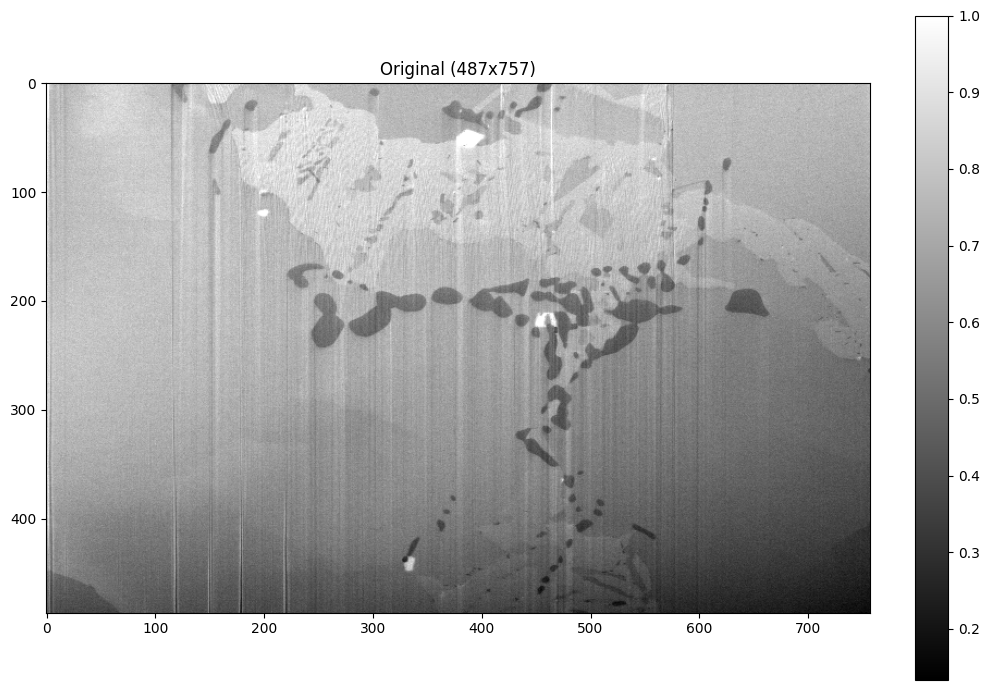

In [2]:
img = np.array(Image.open('sample.png').convert('L'), dtype=np.float32) / 255.0
F = torch.from_numpy(img)

print('Image shape:', F.shape)
print('Value range: [{:.4f}, {:.4f}]'.format(F.min().item(), F.max().item()))

plt.figure(figsize=(10, 7))
plt.imshow(F.numpy(), cmap='gray')
plt.title('Original ({}x{})'.format(F.shape[0], F.shape[1]))
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

## 2. Run Tiled Processing (n=1, 2, 3)

In [3]:
from remover import UniversalStripeRemover

remover = UniversalStripeRemover(mu1=0.33, mu2=0.003)

results = {}
timings = {}

for n_tile in [1, 2, 3]:
    label = '{}x{}'.format(n_tile, n_tile)
    print('\n' + '='*60)
    print('Processing: n={} ({})'.format(n_tile, label))
    print('='*60)
    
    t0 = time.time()
    result = remover.process_tiled(
        F, n=n_tile, iterations=500, tol=1e-5,
        overlap=64, proj=True, verbose=True
    )
    elapsed = time.time() - t0
    
    results[n_tile] = result
    timings[n_tile] = elapsed
    print('Time: {:.1f}s | Shape: {} | Range: [{:.4f}, {:.4f}]'.format(
        elapsed, result.shape, result.min().item(), result.max().item()))

print('\n--- Timing Summary ---')
for n_tile, t in timings.items():
    print('  n={}: {:.1f}s'.format(n_tile, t))


Processing: n=1 (1x1)
Iteration: 500 / 500
Time: 3.7s | Shape: torch.Size([487, 757]) | Range: [0.1968, 0.9906]

Processing: n=2 (2x2)
Tiling 2×2: 4 tiles of 366×501, overlap=61
Iteration: 500 / 500
Time: 3.4s | Shape: torch.Size([487, 757]) | Range: [0.1626, 1.0000]

Processing: n=3 (3x3)
Tiling 3×3: 9 tiles of 243×333, overlap=40
Iteration: 500 / 500
Time: 3.4s | Shape: torch.Size([487, 757]) | Range: [0.1558, 1.0000]

--- Timing Summary ---
  n=1: 3.7s
  n=2: 3.4s
  n=3: 3.4s


## 3. Visual Comparison (n=1, 2, 3)

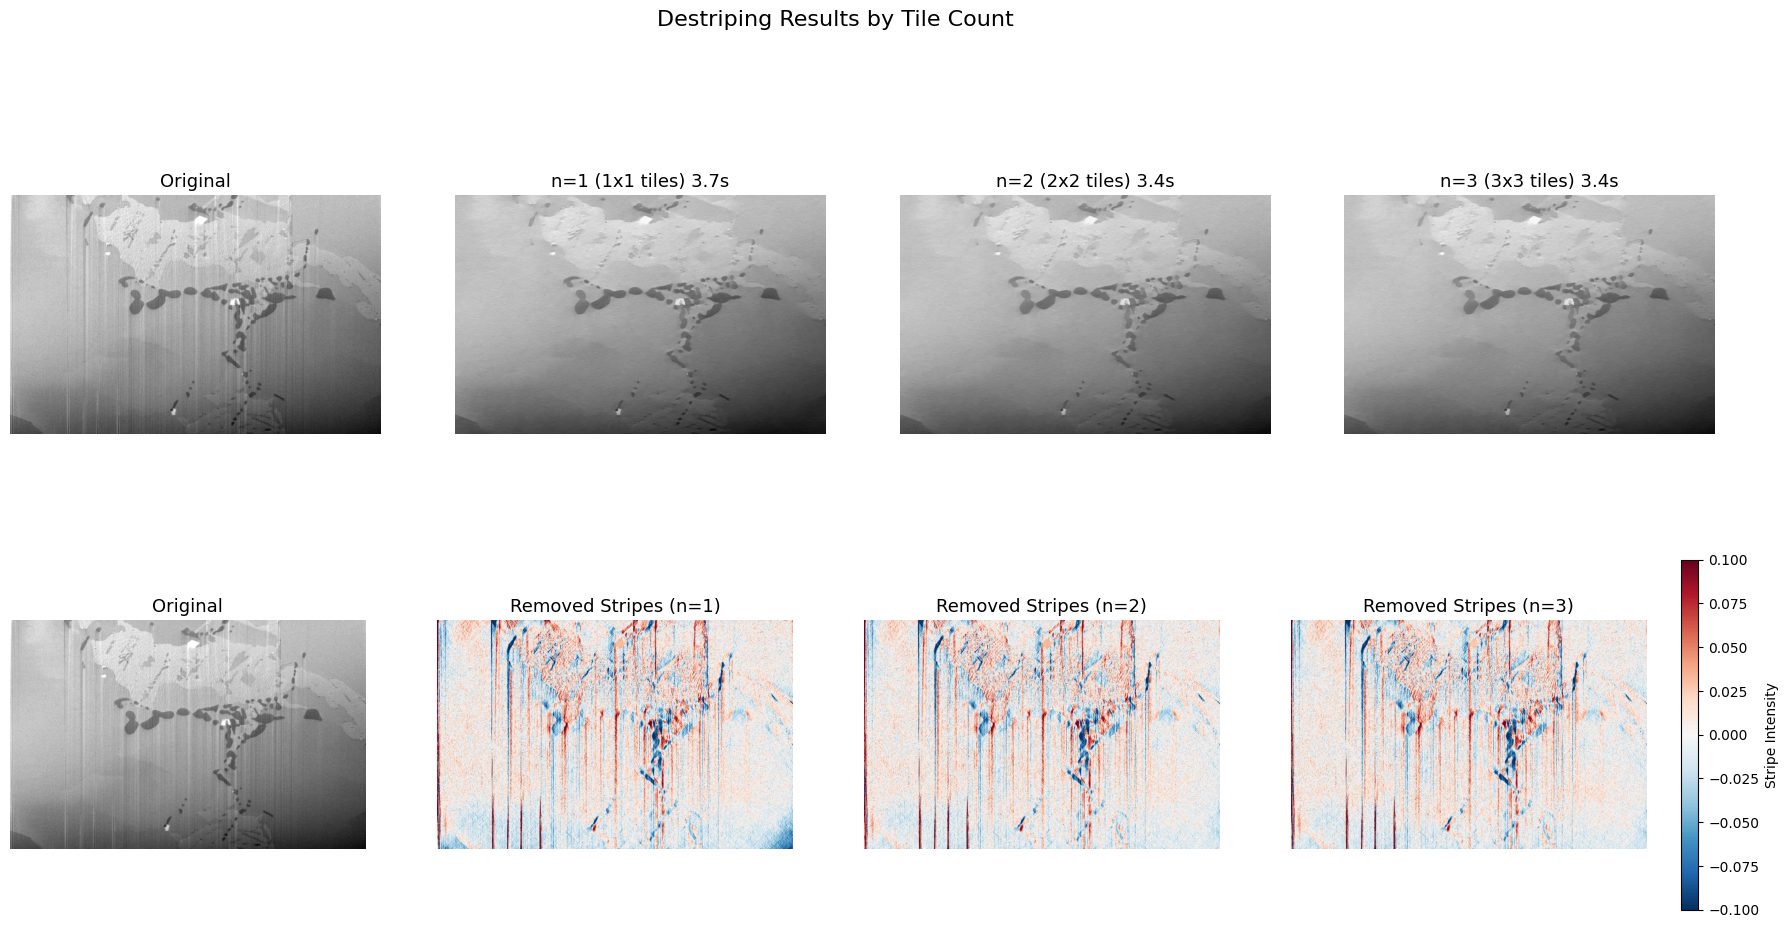

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# Row 1: Destriped images
axes[0, 0].imshow(F.numpy(), cmap='gray')
axes[0, 0].set_title('Original', fontsize=13)

for idx, n_tile in enumerate([1, 2, 3]):
    ax = axes[0, idx + 1]
    ax.imshow(results[n_tile].numpy(), cmap='gray')
    ax.set_title('n={} ({}x{} tiles) {:.1f}s'.format(n_tile, n_tile, n_tile, timings[n_tile]), fontsize=13)

# Row 2: Removed stripe component
vmin, vmax = -0.1, 0.1

axes[1, 0].imshow(F.numpy(), cmap='gray')
axes[1, 0].set_title('Original', fontsize=13)

for idx, n_tile in enumerate([1, 2, 3]):
    ax = axes[1, idx + 1]
    stripe = (F - results[n_tile]).numpy()
    im = ax.imshow(stripe, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.set_title('Removed Stripes (n={})'.format(n_tile), fontsize=13)

for ax in axes.flat:
    ax.axis('off')

fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.02, pad=0.02, label='Stripe Intensity')
plt.suptitle('Destriping Results by Tile Count', fontsize=16, y=1.01)
plt.show()

## 4. Seamless Check — Zoom into Tile Boundaries

If the overlap blending works, there should be **no visible seams** at tile boundaries.

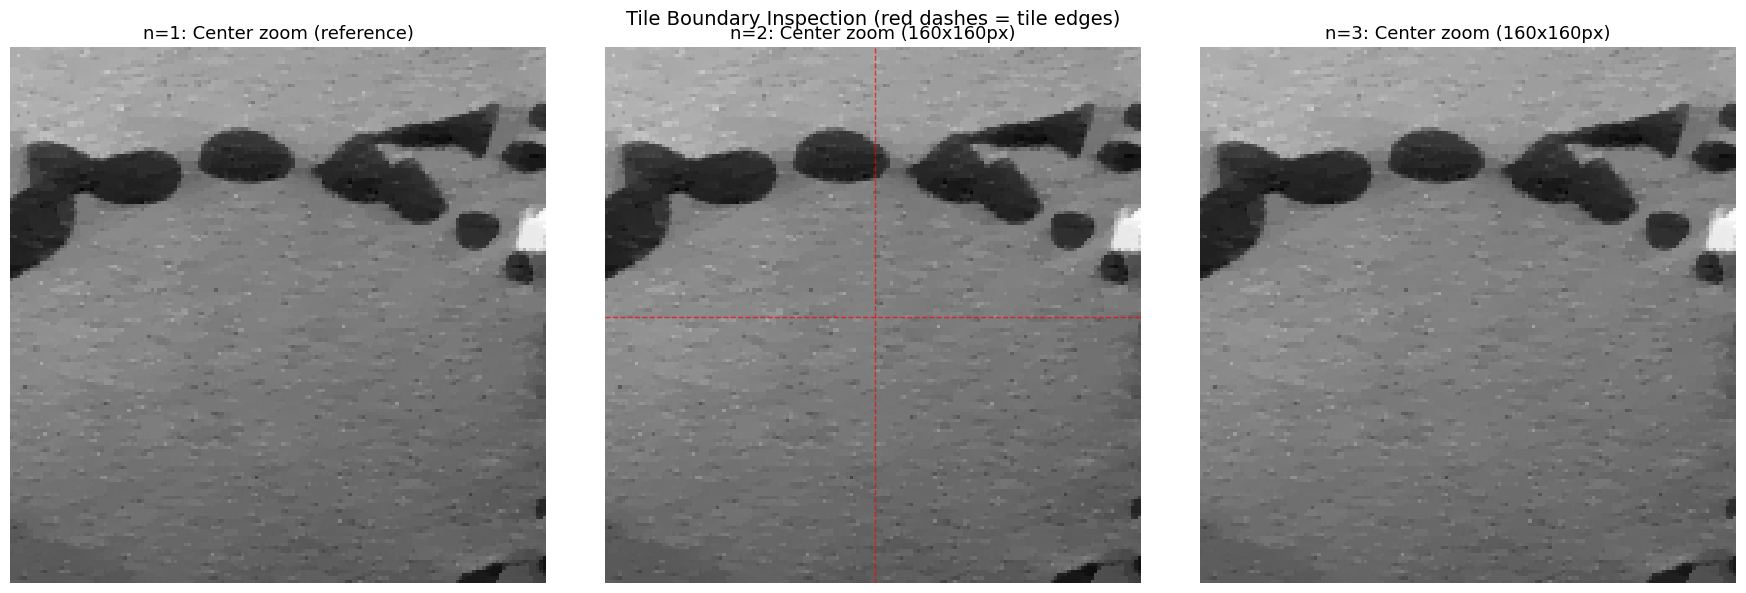

In [5]:
H, W = F.shape

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, n_tile in enumerate([1, 2, 3]):
    ax = axes[idx]
    res = results[n_tile].numpy()
    
    cy, cx = H // 2, W // 2
    margin = 80
    region = res[cy - margin:cy + margin, cx - margin:cx + margin]
    ax.imshow(region, cmap='gray')
    
    if n_tile >= 2:
        ax.set_title('n={}: Center zoom ({}x{}px)'.format(n_tile, 2*margin, 2*margin), fontsize=13)
        tile_h, tile_w = H // n_tile, W // n_tile
        for ti in range(1, n_tile):
            by = ti * tile_h - (cy - margin)
            bx = ti * tile_w - (cx - margin)
            if 0 <= by < 2 * margin:
                ax.axhline(y=by, color='red', linewidth=1, linestyle='--', alpha=0.7)
            if 0 <= bx < 2 * margin:
                ax.axvline(x=bx, color='red', linewidth=1, linestyle='--', alpha=0.7)
    else:
        ax.set_title('n=1: Center zoom (reference)', fontsize=13)
    ax.axis('off')

plt.suptitle('Tile Boundary Inspection (red dashes = tile edges)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Line Profile across Tile Boundaries

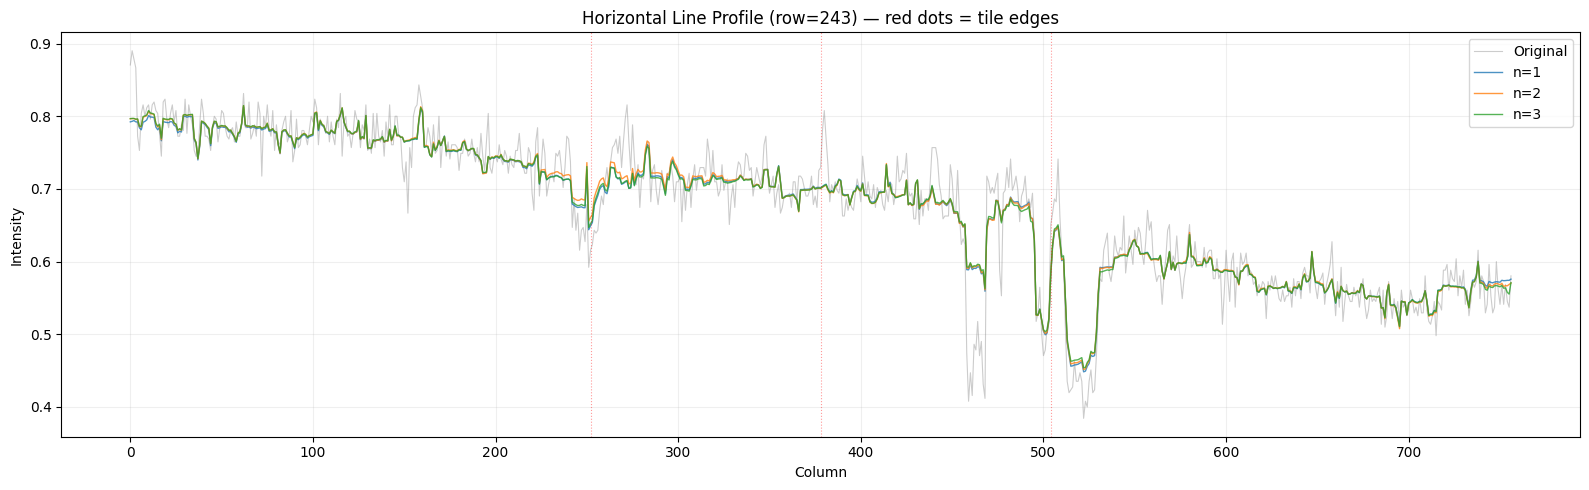

In [6]:
row = H // 2

plt.figure(figsize=(16, 5))
plt.plot(F[row, :].numpy(), alpha=0.4, label='Original', linewidth=0.8, color='gray')
for n_tile in [1, 2, 3]:
    plt.plot(results[n_tile][row, :].numpy(), alpha=0.8, label='n={}'.format(n_tile), linewidth=1.0)

for n_tile in [2, 3]:
    tw = W // n_tile
    for tj in range(1, n_tile):
        plt.axvline(x=tj * tw, color='red', linewidth=0.8, linestyle=':', alpha=0.4)

plt.title('Horizontal Line Profile (row={}) — red dots = tile edges'.format(row))
plt.xlabel('Column')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Quantitative Comparison (n=1 as reference)

In [7]:
ref = results[1]

header = '{:>5} | {:>18} | {:>10} | {:>20}'.format('n', 'Rel. Diff vs n=1', 'Max Diff', 'PSNR(input->result)')
print(header)
print('-' * len(header))

for n_tile in [1, 2, 3]:
    res = results[n_tile]
    rel_diff = torch.norm(res - ref) / torch.norm(ref)
    max_diff = (res - ref).abs().max()
    
    mse = torch.mean((F - res) ** 2)
    if mse > 0:
        psnr = 10 * torch.log10(1.0 / mse)
    else:
        psnr = torch.tensor(float('inf'))
    
    print('{:>5} | {:>18.6f} | {:>10.6f} | {:>18.2f} dB'.format(
        n_tile, rel_diff.item(), max_diff.item(), psnr.item()))

    n |   Rel. Diff vs n=1 |   Max Diff |  PSNR(input->result)
--------------------------------------------------------------
    1 |           0.000000 |   0.000000 |              30.51 dB
    2 |           0.007137 |   0.099677 |              30.68 dB
    3 |           0.007779 |   0.106928 |              30.63 dB


## 7. Adjoint Consistency Test

In [8]:
from remover import UniversalStripeRemover

r = UniversalStripeRemover(device='cpu')
shape = (1, 32, 32)
torch.manual_seed(42)

print('=== Adjoint Consistency: <Df, g> == <f, D^T g> ===')
print('{:<12} {:>16} {:>16} {:>12} {:>5}'.format('Operator', '<Df, g>', '<f, D^T g>', 'Rel Error', ''))
print('-' * 65)

all_pass = True
labels = ['vert(0)', '26.6L', '45L', '26.6R', '45R']

for mode in range(5):
    f_vec = torch.randn(shape)
    g_vec = torch.randn(shape)
    Df = r._dir_diff(f_vec, mode)
    DTg = torch.zeros_like(g_vec)
    r._adj_dir(DTg, g_vec, mode, 1.0)
    DTg = -DTg
    lhs = torch.sum(Df * g_vec).item()
    rhs = torch.sum(f_vec * DTg).item()
    err = abs(lhs - rhs) / (abs(lhs) + 1e-12)
    ok = err < 1e-5
    all_pass = all_pass and ok
    status = 'PASS' if ok else 'FAIL'
    print('{:<12} {:>16.8f} {:>16.8f} {:>12.2e} {:>5}'.format(labels[mode], lhs, rhs, err, status))

for dim, name in [(1, 'grad_h'), (2, 'grad_v')]:
    f_vec = torch.randn(shape)
    g_vec = torch.randn(shape)
    Df = r._fwd(f_vec, dim)
    DTg = torch.zeros_like(g_vec)
    if dim == 1:
        r._adj_grad(DTg, g_vec, torch.zeros_like(g_vec), 1.0)
    else:
        r._adj_grad(DTg, torch.zeros_like(g_vec), g_vec, 1.0)
    DTg = -DTg
    lhs = torch.sum(Df * g_vec).item()
    rhs = torch.sum(f_vec * DTg).item()
    err = abs(lhs - rhs) / (abs(lhs) + 1e-12)
    ok = err < 1e-5
    all_pass = all_pass and ok
    status = 'PASS' if ok else 'FAIL'
    print('{:<12} {:>16.8f} {:>16.8f} {:>12.2e} {:>5}'.format(name, lhs, rhs, err, status))

print()
if all_pass:
    print('All tests PASSED')
else:
    print('Some tests FAILED')

=== Adjoint Consistency: <Df, g> == <f, D^T g> ===
Operator              <Df, g>       <f, D^T g>    Rel Error      
-----------------------------------------------------------------
vert(0)           29.85549927      29.85549927     0.00e+00  PASS
26.6L           -100.50484467    -100.50484467     0.00e+00  PASS
45L              -67.93233490     -67.93232727     1.12e-07  PASS
26.6R            -17.86000443     -17.86001205     4.27e-07  PASS
45R               37.39154053      37.39154053     0.00e+00  PASS
grad_h           -27.56414986     -27.56415558     2.08e-07  PASS
grad_v           -40.49197769     -40.49198151     9.42e-08  PASS

All tests PASSED
